# 3 домашка по биоинформатике. 5 задание

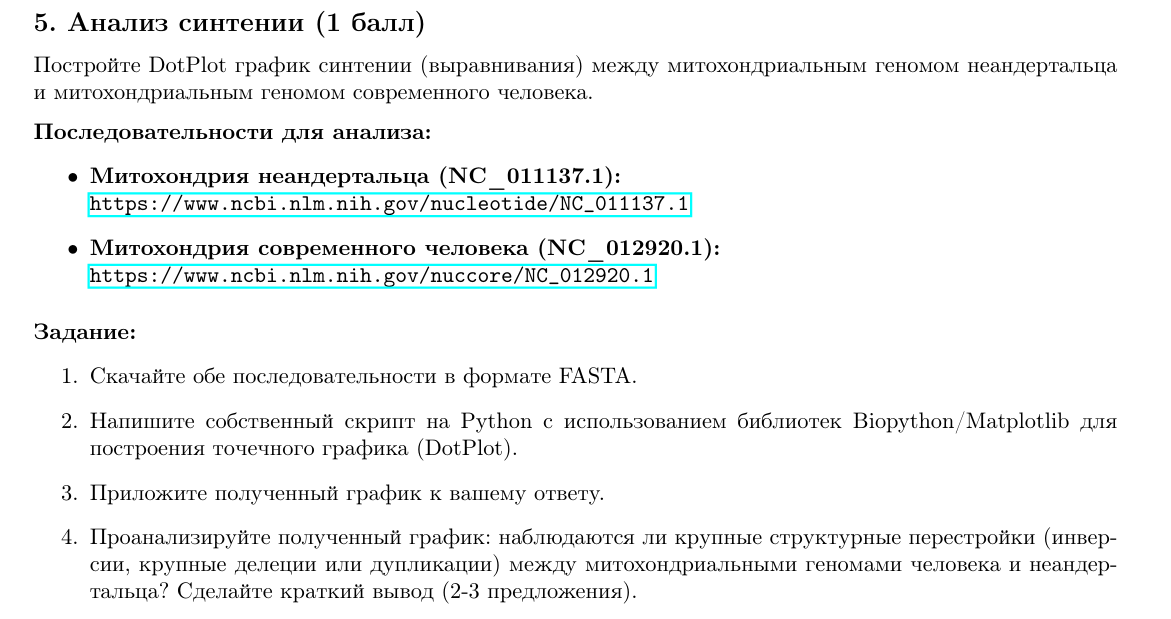

In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
from matplotlib import pyplot as plt

In [2]:
a = SeqIO.read("sequence_Homo_sapiens.fasta", "fasta")
sapience = str(a.seq)

b = SeqIO.read("sequence_Homo_sapiens_neanderthalensis.fasta", "fasta")
neand = str(b.seq)

Идея:

идем по геному неандертальца окошком по k нуклеотидов (к-мером) и записываем в словарь (остатки:индекс i) - это index в коде. Потом идём по геному человека, берём к-мер оттуда и ищем его в словаре index - если такой к-мер есть в геноме неандертальца, то получаем все позиции j, где он встречается, как значения ключа к-мера.

Потом строим обратную комплементарную последовательность (я нашла функцию reverse_complement()) и делаем тот же поиск к-меров

In [53]:
k=15

In [54]:
index = {} #здесь будет к-мер : позиции во геноме неандертальца

for j in range(len(neand) - k + 1):
    kmer = neand[j:j+k]
    if kmer in index:
        index[kmer].append(j)
    else:
        index[kmer] = [j]   

Вперед:

In [55]:
x_forward = []
y_forward = []

for i in range(len(sapience) - k + 1):
    kmer = sapience[i:i+k]
    if kmer in index:
        for j in index[kmer]:
            x_forward.append(i)
            y_forward.append(j)

Назад:

In [56]:
sapience_rev = str(Seq(sapience).reverse_complement())
x_reverse = []
y_reverse = []

for i in range(len(sapience_rev) - k + 1):
    kmer = sapience_rev[i:i+k]
    if kmer in index:
        for j in index[kmer]:
            x_reverse.append(i)
            y_reverse.append(j)

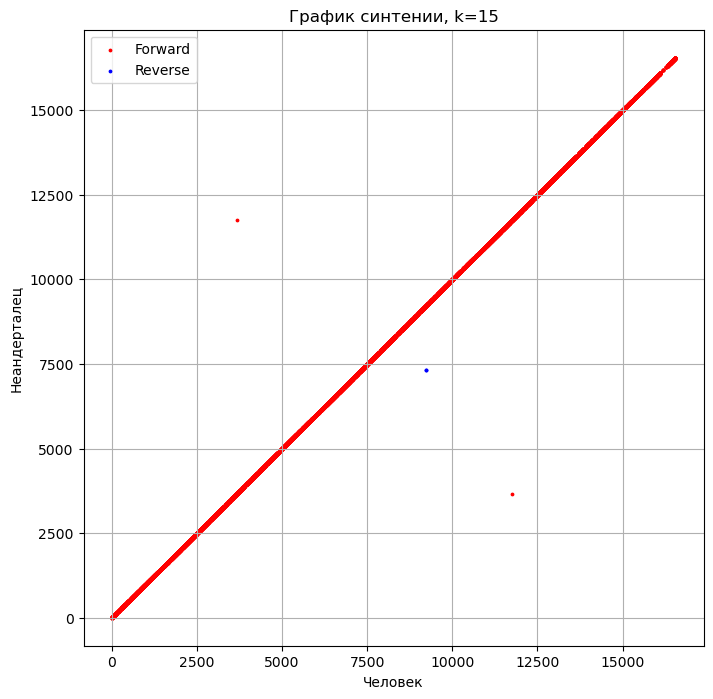

In [57]:
plt.figure(figsize=(8,8))
plt.scatter(x_forward, y_forward, s=3, color="red", label="Forward")
plt.scatter(x_reverse, y_reverse, s=3, color="blue", label="Reverse")

plt.xlabel("Человек")
plt.ylabel("Неандерталец")
plt.title(f"График синтении, k={k}")

plt.legend()
plt.grid()

Объединим в функцию, чтобы посмотреть графики при различных значениях k:

In [58]:
def syntenia(k):
    index = {}

    for j in range(len(neand) - k + 1):
        kmer = neand[j:j+k]
        if kmer in index:
            index[kmer].append(j)
        else:
            index[kmer] = [j]
    x_forward = []
    y_forward = []

    for i in range(len(sapience) - k + 1):
        kmer = sapience[i:i+k]
        if kmer in index:
            for j in index[kmer]:
                x_forward.append(i)
                y_forward.append(j)
                
    sapience_rev = str(Seq(sapience).reverse_complement())
    x_reverse = []
    y_reverse = []

    for i in range(len(sapience_rev) - k + 1):
        kmer = sapience_rev[i:i+k]
        if kmer in index:
            for j in index[kmer]:
                x_reverse.append(i)
                y_reverse.append(j)
    plt.figure(figsize=(8,8))
    plt.scatter(x_forward, y_forward, s=3, color="red", label="Forward")
    plt.scatter(x_reverse, y_reverse, s=3, color="blue", label="Reverse")

    plt.xlabel("Человек")
    plt.ylabel("Неандерталец")
    plt.title(f"График синтении, k={k}")

    plt.legend()
    plt.grid()

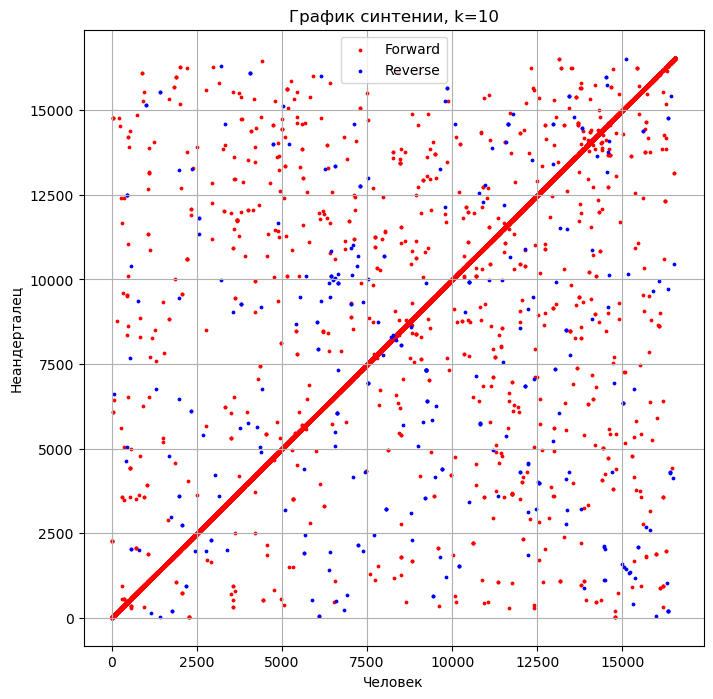

In [62]:
syntenia(k=10)

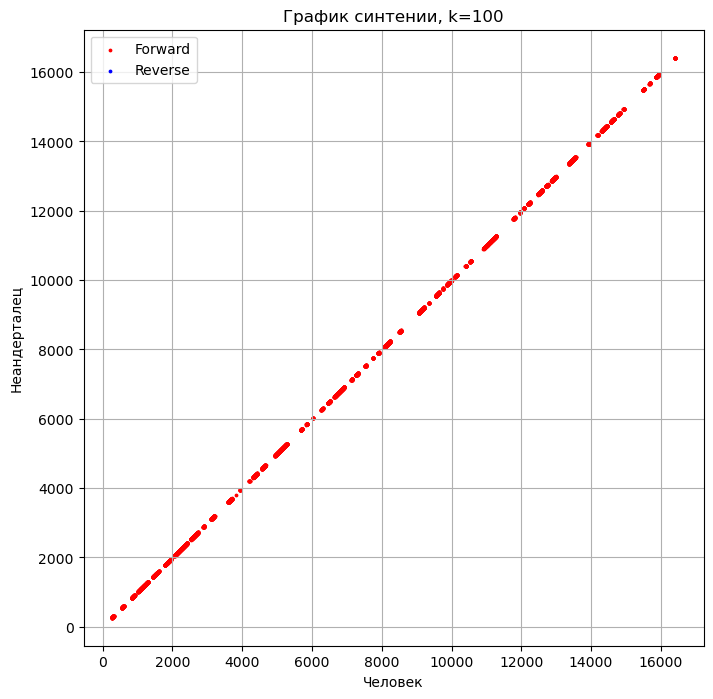

In [60]:
syntenia(k=100)

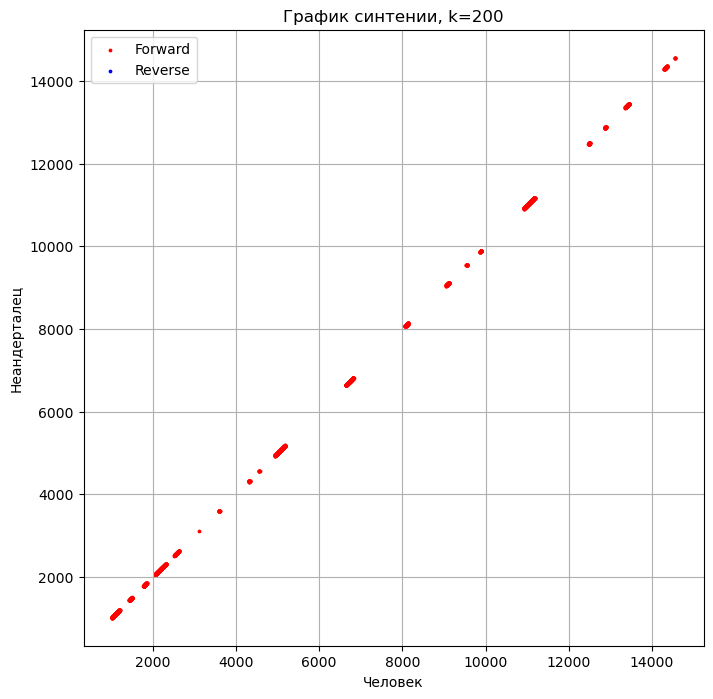

In [63]:
syntenia(k=200)

**Вывод**

На графиках синтении точки образуют чёткую главную диагональ, что говорит о практически полном совпадении порядка участков ДНК в митохондриальных геномах человека и неандертальца. Разрывов или обратных диагоналей нет, поэтому крупных перестроек (инверсий, дупликаций и т.п.) нет.
Даже при k = 100 диагональ остаётся чёткой, что показывает, что геномы очень близки, а различия между ними в основном ограничиваются небольшими локальными мутациями.
